In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

file_path = "C:/Users/Rajiv/Desktop/Bhav/Yuva Intern Data Science with Python Trainee/Dataset/adult.data"

columns = [
    "age",
    "workclass",
    "fnlwgt",
    "education",
    "education_num",
    "marital_status",
    "occupation",
    "relationship",
    "race",
    "sex",
    "capital_gain",
    "capital_loss",
    "hours_per_week",
    "native_country",
    "income"
]

df = pd.read_csv(
    file_path,
    names=columns,
    na_values="?",
    skipinitialspace=True
)

In [10]:
df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [11]:
df.shape

(32561, 15)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       30725 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education_num   32561 non-null  int64 
 5   marital_status  32561 non-null  object
 6   occupation      30718 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital_gain    32561 non-null  int64 
 11  capital_loss    32561 non-null  int64 
 12  hours_per_week  32561 non-null  int64 
 13  native_country  31978 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [13]:
df.describe()

,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [14]:
df.describe(include="object")

,workclass,education,marital_status,occupation,relationship,race,sex,native_country,income
count,30725,32561,32561,30718,32561,32561,32561,31978,32561
unique,8,16,7,14,6,5,2,41,2
top,Private,HS-grad,Married-civ-spouse,Prof-specialty,Husband,White,Male,United-States,<=50K
freq,22696,10501,14976,4140,13193,27816,21790,29170,24720


In [15]:
df.isnull().sum()

age                  0
workclass         1836
fnlwgt               0
education            0
education_num        0
marital_status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital_gain         0
capital_loss         0
hours_per_week       0
native_country     583
income               0
dtype: int64

In [16]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_percentage

age               0.000000
workclass         5.638647
fnlwgt            0.000000
education         0.000000
education_num     0.000000
marital_status    0.000000
occupation        5.660146
relationship      0.000000
race              0.000000
sex               0.000000
capital_gain      0.000000
capital_loss      0.000000
hours_per_week    0.000000
native_country    1.790486
income            0.000000
dtype: float64

In [17]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 24


In [18]:
duplicate_percentage = (duplicate_count / len(df)) * 100

print(f"Duplicate percentage: {duplicate_percentage:.2f}%")

Duplicate percentage: 0.07%


In [19]:
categorical_columns = df.select_dtypes(include="object").columns

for column in categorical_columns:
    print(f"\n--- {column} ---")
    print(df[column].value_counts())


--- workclass ---
workclass
Private             22696
Self-emp-not-inc     2541
Local-gov            2093
State-gov            1298
Self-emp-inc         1116
Federal-gov           960
Without-pay            14
Never-worked            7
Name: count, dtype: int64

--- education ---
education
HS-grad         10501
Some-college     7291
Bachelors        5355
Masters          1723
Assoc-voc        1382
11th             1175
Assoc-acdm       1067
10th              933
7th-8th           646
Prof-school       576
9th               514
12th              433
Doctorate         413
5th-6th           333
1st-4th           168
Preschool          51
Name: count, dtype: int64

--- marital_status ---
marital_status
Married-civ-spouse       14976
Never-married            10683
Divorced                  4443
Separated                 1025
Widowed                    993
Married-spouse-absent      418
Married-AF-spouse           23
Name: count, dtype: int64

--- occupation ---
occupation
Prof-specialty   

In [20]:
for column in categorical_columns:
    values = df[column].dropna()

    leading_spaces = values[values.str.startswith(" ")]
    trailing_spaces = values[values.str.endswith(" ")]

    print(f"\n{column}")
    print("Leading spaces:", len(leading_spaces))
    print("Trailing spaces:", len(trailing_spaces))


workclass
Leading spaces: 0
Trailing spaces: 0

education
Leading spaces: 0
Trailing spaces: 0

marital_status
Leading spaces: 0
Trailing spaces: 0

occupation
Leading spaces: 0
Trailing spaces: 0

relationship
Leading spaces: 0
Trailing spaces: 0

race
Leading spaces: 0
Trailing spaces: 0

sex
Leading spaces: 0
Trailing spaces: 0

native_country
Leading spaces: 0
Trailing spaces: 0

income
Leading spaces: 0
Trailing spaces: 0


In [21]:
for column in categorical_columns:
    print(f"\n--- {column} ---")
    print(df[column].value_counts(dropna=False))


--- workclass ---
workclass
Private             22696
Self-emp-not-inc     2541
Local-gov            2093
NaN                  1836
State-gov            1298
Self-emp-inc         1116
Federal-gov           960
Without-pay            14
Never-worked            7
Name: count, dtype: int64

--- education ---
education
HS-grad         10501
Some-college     7291
Bachelors        5355
Masters          1723
Assoc-voc        1382
11th             1175
Assoc-acdm       1067
10th              933
7th-8th           646
Prof-school       576
9th               514
12th              433
Doctorate         413
5th-6th           333
1st-4th           168
Preschool          51
Name: count, dtype: int64

--- marital_status ---
marital_status
Married-civ-spouse       14976
Never-married            10683
Divorced                  4443
Separated                 1025
Widowed                    993
Married-spouse-absent      418
Married-AF-spouse           23
Name: count, dtype: int64

--- occupation ---
oc

In [22]:
numeric_columns = df.select_dtypes(include="number").columns

print("Numerical columns:")
print(list(numeric_columns))

Numerical columns:
['age', 'fnlwgt', 'education_num', 'capital_gain', 'capital_loss', 'hours_per_week']


In [23]:
for column in numeric_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ]
    
    print(f"\n--- {column} ---")
    print(f"Q1: {Q1}")
    print(f"Q3: {Q3}")
    print(f"IQR: {IQR}")
    print(f"Lower Bound: {lower_bound}")
    print(f"Upper Bound: {upper_bound}")
    print(f"Number of outliers: {len(outliers)}")


--- age ---
Q1: 28.0
Q3: 48.0
IQR: 20.0
Lower Bound: -2.0
Upper Bound: 78.0
Number of outliers: 143

--- fnlwgt ---
Q1: 117827.0
Q3: 237051.0
IQR: 119224.0
Lower Bound: -61009.0
Upper Bound: 415887.0
Number of outliers: 992

--- education_num ---
Q1: 9.0
Q3: 12.0
IQR: 3.0
Lower Bound: 4.5
Upper Bound: 16.5
Number of outliers: 1198

--- capital_gain ---
Q1: 0.0
Q3: 0.0
IQR: 0.0
Lower Bound: 0.0
Upper Bound: 0.0
Number of outliers: 2712

--- capital_loss ---
Q1: 0.0
Q3: 0.0
IQR: 0.0
Lower Bound: 0.0
Upper Bound: 0.0
Number of outliers: 1519

--- hours_per_week ---
Q1: 40.0
Q3: 45.0
IQR: 5.0
Lower Bound: 32.5
Upper Bound: 52.5
Number of outliers: 9008


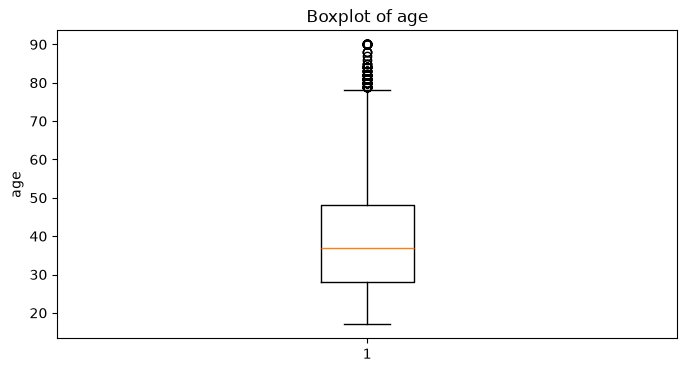

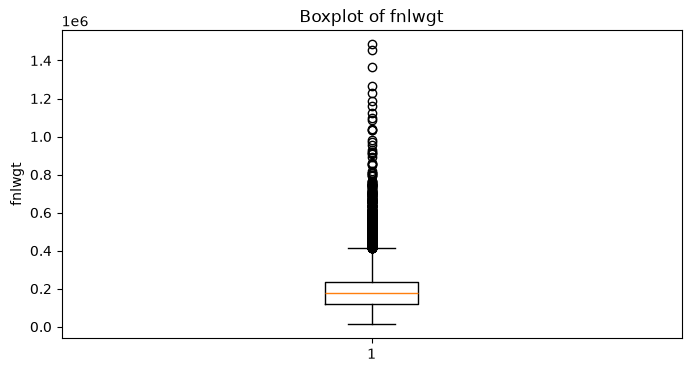

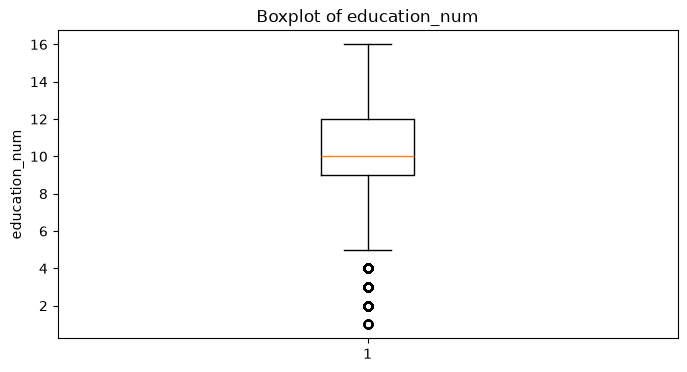

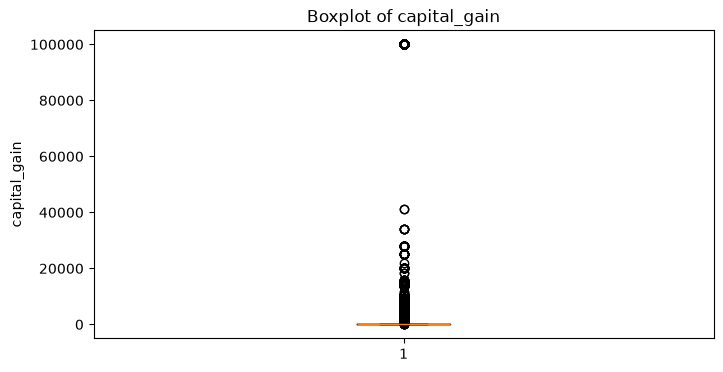

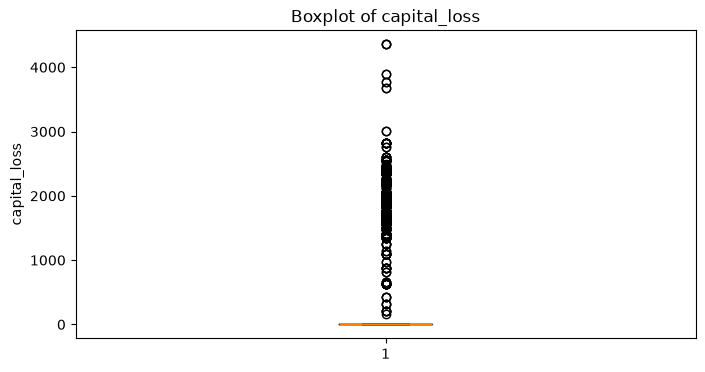

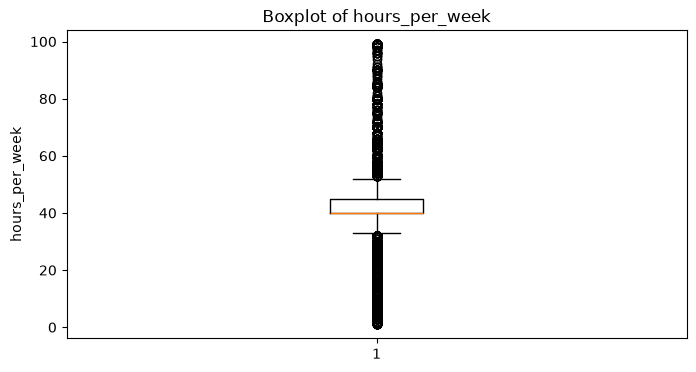

In [24]:
for column in numeric_columns:
    plt.figure(figsize=(8, 4))
    plt.boxplot(df[column].dropna())
    plt.title(f"Boxplot of {column}")
    plt.ylabel(column)
    plt.show()

In [26]:
# Create a copy so the original dataset remains unchanged
df_cleaned = df.copy()

# Replace missing categorical values with "Unknown"
categorical_missing_columns = [
    "workclass",
    "occupation",
    "native_country"
]

for column in categorical_missing_columns:
    df_cleaned[column] = df_cleaned[column].fillna("Unknown")

In [27]:
df_cleaned[categorical_missing_columns].isnull().sum()

workclass         0
occupation        0
native_country    0
dtype: int64

In [28]:
before_duplicates = len(df_cleaned)

df_cleaned = df_cleaned.drop_duplicates()

after_duplicates = len(df_cleaned)

print("Rows before removing duplicates:", before_duplicates)
print("Duplicate rows removed:", before_duplicates - after_duplicates)
print("Rows after removing duplicates:", after_duplicates)

Rows before removing duplicates: 32561
Duplicate rows removed: 24
Rows after removing duplicates: 32537


In [29]:
print("Remaining duplicate rows:", df_cleaned.duplicated().sum())

Remaining duplicate rows: 0


In [30]:
print("Dataset shape after cleaning:", df_cleaned.shape)

print("\nMissing values:")
print(df_cleaned.isnull().sum())

print("\nDuplicate rows:")
print(df_cleaned.duplicated().sum())

Dataset shape after cleaning: (32537, 15)

Missing values:
age               0
workclass         0
fnlwgt            0
education         0
education_num     0
marital_status    0
occupation        0
relationship      0
race              0
sex               0
capital_gain      0
capital_loss      0
hours_per_week    0
native_country    0
income            0
dtype: int64

Duplicate rows:
0


In [32]:
outlier_summary = []

for column in numeric_columns:
    Q1 = df_cleaned[column].quantile(0.25)
    Q3 = df_cleaned[column].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outlier_count = (
        (df_cleaned[column] < lower_bound) |
        (df_cleaned[column] > upper_bound)
    ).sum()
    
    outlier_summary.append({
        "Column": column,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Potential Outliers": outlier_count
    })

outlier_summary_df = pd.DataFrame(outlier_summary)

outlier_summary_df

,Column,Q1,Q3,IQR,Lower Bound,Upper Bound,Potential Outliers
0,age,28.0,48.0,20.0,-2.0,78.0,142
1,fnlwgt,117827.0,236993.0,119166.0,-60922.0,415742.0,993
2,education_num,9.0,12.0,3.0,4.5,16.5,1193
3,capital_gain,0.0,0.0,0.0,0.0,0.0,2712
4,capital_loss,0.0,0.0,0.0,0.0,0.0,1519
5,hours_per_week,40.0,45.0,5.0,32.5,52.5,9002


In [33]:
print("Age below 0:", (df_cleaned["age"] < 0).sum())
print("Age above 100:", (df_cleaned["age"] > 100).sum())

print("Hours below 0:", (df_cleaned["hours_per_week"] < 0).sum())
print("Hours above 168:", (df_cleaned["hours_per_week"] > 168).sum())

print("Education number below 1:", (df_cleaned["education_num"] < 1).sum())
print("Education number above 16:", (df_cleaned["education_num"] > 16).sum())

Age below 0: 0
Age above 100: 0
Hours below 0: 0
Hours above 168: 0
Education number below 1: 0
Education number above 16: 0


In [34]:
print("Data types:")
print(df_cleaned.dtypes)

print("\nMissing values:")
print(df_cleaned.isnull().sum().sum())

print("\nDuplicate rows:")
print(df_cleaned.duplicated().sum())

print("\nDataset shape:")
print(df_cleaned.shape)

Data types:
age                int64
workclass         object
fnlwgt             int64
education         object
education_num      int64
marital_status    object
occupation        object
relationship      object
race              object
sex               object
capital_gain       int64
capital_loss       int64
hours_per_week     int64
native_country    object
income            object
dtype: object

Missing values:
0

Duplicate rows:
0

Dataset shape:
(32537, 15)


In [35]:
for column in ["workclass", "occupation", "native_country"]:
    print(f"\n{column}:")
    print(df_cleaned[column].value_counts())


workclass:
workclass
Private             22673
Self-emp-not-inc     2540
Local-gov            2093
Unknown              1836
State-gov            1298
Self-emp-inc         1116
Federal-gov           960
Without-pay            14
Never-worked            7
Name: count, dtype: int64

occupation:
occupation
Prof-specialty       4136
Craft-repair         4094
Exec-managerial      4065
Adm-clerical         3768
Sales                3650
Other-service        3291
Machine-op-inspct    2000
Unknown              1843
Transport-moving     1597
Handlers-cleaners    1369
Farming-fishing       992
Tech-support          927
Protective-serv       649
Priv-house-serv       147
Armed-Forces            9
Name: count, dtype: int64

native_country:
native_country
United-States                 29153
Mexico                          639
Unknown                         582
Philippines                     198
Germany                         137
Canada                          121
Puerto-Rico                   

In [36]:
cleaned_file = "adult_cleaned.csv"

df_cleaned.to_csv(cleaned_file, index=False)

print(f"Cleaned dataset saved as: {cleaned_file}")

Cleaned dataset saved as: adult_cleaned.csv


In [37]:
import os

print(os.getcwd())
print(os.path.exists("adult_cleaned.csv"))

C:\Users\Rajiv\Desktop\Bhav\Yuva Intern Data Science with Python Trainee
True


In [39]:
X = df_cleaned.drop("income", axis=1)
y = df_cleaned["income"]
y = y.str.strip().str.replace(".", "", regex=False)

print(y.value_counts())

income
<=50K    24698
>50K      7839
Name: count, dtype: int64


In [40]:
y = y.map({
    "<=50K": 0,
    ">50K": 1
})

print(y.value_counts())

income
0    24698
1     7839
Name: count, dtype: int64


In [41]:
X_encoded = pd.get_dummies(
    X,
    columns=X.select_dtypes(include="object").columns,
    drop_first=True
)

print("Original feature count:", X.shape[1])
print("Encoded feature count:", X_encoded.shape[1])

Original feature count: 14
Encoded feature count: 100


In [42]:
df_preprocessed = pd.concat(
    [X_encoded, y.rename("income")],
    axis=1
)

print(df_preprocessed.shape)
print(df_preprocessed.head())

(32537, 101)
   age  fnlwgt  education_num  capital_gain  capital_loss  hours_per_week  \
0   39   77516             13          2174             0              40   
1   50   83311             13             0             0              13   
2   38  215646              9             0             0              40   
3   53  234721              7             0             0              40   
4   28  338409             13             0             0              40   

   workclass_Local-gov  workclass_Never-worked  workclass_Private  \
0                False                   False              False   
1                False                   False              False   
2                False                   False               True   
3                False                   False               True   
4                False                   False               True   

   workclass_Self-emp-inc  ...  native_country_Scotland  native_country_South  \
0                   False  .

In [43]:
preprocessed_file = "adult_preprocessed.csv"

df_preprocessed.to_csv(
    preprocessed_file,
    index=False
)

print(f"Preprocessed dataset saved as: {preprocessed_file}")

Preprocessed dataset saved as: adult_preprocessed.csv


In [44]:
print("FINAL DATASET VALIDATION")
print("=" * 40)

print("Cleaned dataset shape:", df_cleaned.shape)
print("Missing values:", df_cleaned.isnull().sum().sum())
print("Duplicate rows:", df_cleaned.duplicated().sum())

print("\nPreprocessed dataset shape:", df_preprocessed.shape)
print("Preprocessed missing values:", df_preprocessed.isnull().sum().sum())
print("Preprocessed duplicate rows:", df_preprocessed.duplicated().sum())

print("\nFiles created:")
print("adult_cleaned.csv")
print("adult_preprocessed.csv")

FINAL DATASET VALIDATION
Cleaned dataset shape: (32537, 15)
Missing values: 0
Duplicate rows: 0

Preprocessed dataset shape: (32537, 101)
Preprocessed missing values: 0
Preprocessed duplicate rows: 0

Files created:
adult_cleaned.csv
adult_preprocessed.csv
